In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance

trained model feature importance, permutation feature importance for svr

In [2]:
#load the data and params again
DATE_COL = "date"
TARGET_COLS = ["y_h1", "y_h3", "y_h5", "y_h7"]
VAL_RATIO = 0.2

TRAIN_PATH = "../data/train_dataset.csv"
OUT_DIR = "../model feature importance/svr_shap_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# recreate svr param dictionary from summary csv
summary_df = pd.read_csv("../models/svr_final_summary.csv")
final_svr_params = {}

for _, row in summary_df.iterrows():
    target = row["target"]
    
    params = {
        "svr__C": row["svr__C"],
        "svr__epsilon": row["svr__epsilon"],
        "svr__kernel": row["svr__kernel"]
    }
    
    if pd.notna(row.get("svr__gamma", np.nan)):
        params["svr__gamma"] = row["svr__gamma"]
    
    final_svr_params[target] = params

print(final_svr_params)

{'y_h1': {'svr__C': 0.011, 'svr__epsilon': 0.19, 'svr__kernel': 'linear'}, 'y_h3': {'svr__C': 0.5, 'svr__epsilon': 0.1, 'svr__kernel': 'rbf', 'svr__gamma': 'scale'}, 'y_h5': {'svr__C': 0.5, 'svr__epsilon': 0.05, 'svr__kernel': 'rbf', 'svr__gamma': 'scale'}, 'y_h7': {'svr__C': 1.0, 'svr__epsilon': 0.005, 'svr__kernel': 'rbf', 'svr__gamma': 'scale'}}


In [3]:
# Reload data
df = pd.read_csv(TRAIN_PATH)

# use the same date parsing
df[DATE_COL] = pd.to_datetime(df[DATE_COL], format="%d/%m/%y", errors="raise")
df = df.sort_values(DATE_COL).reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

print("Train data shape:", df.shape)
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())

# Recreate train/validation split
cut = int(len(df) * (1 - VAL_RATIO))
train_sub = df.iloc[:cut].copy()
val_sub = df.iloc[cut:].copy()

feature_cols = [c for c in df.columns if c not in [DATE_COL] + TARGET_COLS]

X_train = train_sub[feature_cols]
X_val = val_sub[feature_cols]

print("Sub-train rows:", len(train_sub))
print("Validation rows:", len(val_sub))
print("Validation starts from:", val_sub[DATE_COL].min())
print("Number of features:", len(feature_cols))

Train data shape: (1268, 181)
Date range: 2021-01-08 00:00:00 to 2024-06-28 00:00:00
Sub-train rows: 1014
Validation rows: 254
Validation starts from: 2023-10-19 00:00:00
Number of features: 176


In [12]:
importance_tables = []

for target_col, params in final_svr_params.items():
    y_train = train_sub[target_col]
    y_val = val_sub[target_col]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR())
    ])

    model.set_params(**params)
    model.fit(X_train, y_train)

    perm = permutation_importance(
        model,
        X_val,
        y_val,
        n_repeats=20,
        random_state=42,
        scoring="neg_mean_squared_error"
    )

    imp_df = pd.DataFrame({
        "target": target_col,
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    importance_tables.append(imp_df)

    print(f"\nTop 15 features for {target_col}:")
    print(imp_df.head(15))

svr_feature_importance = pd.concat(importance_tables, ignore_index=True)
svr_feature_importance.to_csv(os.path.join(OUT_DIR, "svr_feature_importance.csv"), index=False)

print("\nSaved:", os.path.join(OUT_DIR, "svr_feature_importance.csv"))


Top 15 features for y_h1:
   target                     feature  importance_mean  importance_std
0    y_h1                      log_RV         0.218949        0.038626
1    y_h1                    HYG_lag1         0.015414        0.003956
2    y_h1    DLOG_EST_TX_VOL_USD_lag2         0.015004        0.004031
3    y_h1          DLOG_TX_COUNT_lag2         0.010296        0.006508
4    y_h1   DLOG_FEES_USD_PER_TX_lag1         0.009795        0.003960
5    y_h1         DLOG_MINERS_REV_USD         0.009225        0.005162
6    y_h1   DLOG_FEES_USD_PER_TX_lag3         0.008910        0.007189
7    y_h1                         IEF         0.008881        0.005103
8    y_h1                  RSI14_lag1         0.008755        0.003032
9    y_h1                    TLT_lag3         0.008230        0.003114
10   y_h1                    LQD_lag3         0.008163        0.003621
11   y_h1  DLOG_AVG_TX_VALUE_USD_lag2         0.007381        0.002145
12   y_h1       DLOG_UNIQUE_ADDR_lag1         0.00

In [13]:
#linear coefficients for y_h1 only
yh1_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

yh1_model.set_params(**final_svr_params["y_h1"])
yh1_model.fit(X_train, train_sub["y_h1"])

coef = yh1_model.named_steps["svr"].coef_.flatten()

yh1_coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

yh1_coef_df.to_csv(os.path.join(OUT_DIR, "svr_yh1_linear_coefficients.csv"), index=False)

print("Top 15 absolute coefficients for y_h1:")
print(yh1_coef_df.head(15))

Top 15 absolute coefficients for y_h1:
                  feature      coef  abs_coef
0                  log_RV  0.414996  0.414996
1                IEF_lag1  0.099535  0.099535
2            D_DGS10_lag3 -0.088457  0.088457
3              ATR14_lag2  0.085051  0.085051
4   DLOG_UNIQUE_ADDR_lag1 -0.084733  0.084733
5             log_RV_lag1  0.081642  0.081642
6                HYG_lag1 -0.080903  0.080903
7             log_RV_lag2  0.077170  0.077170
8              RSI14_lag3 -0.069938  0.069938
9             log_RV_lag3  0.066416  0.066416
10                    IEF -0.059226  0.059226
11            NASDAQ_lag3  0.049760  0.049760
12               LQD_lag3 -0.046779  0.046779
13              GOLD_lag3 -0.045476  0.045476
14                STOCH_K -0.044731  0.044731


oos rolling window PFI for svr

In [ ]:
FULL_DATA_PATH = "../data/full_df.csv"

HORIZONS = [1, 3, 5, 7]
WINDOW_SIZE = 1095
EVAL_START_DATE = pd.to_datetime("2024-06-29")

REFIT_EVERY = 7
N_IMPORTANCE_STEP = REFIT_EVERY
# if later you want a faster sampled version instead, use this instead:
# N_IMPORTANCE_STEP = REFIT_EVERY * 5

SEED = 42

# Feature group mapping (match XGB's script)
FEATURE_GROUPS = {
    # Macroeconomic
    "DOW30": "Macro",
    "FTSE100": "Macro",
    "NASDAQ": "Macro",
    "SP500": "Macro",
    "SSE": "Macro",
    "VIX": "Macro",
    "OIL": "Macro",
    "DXY": "Macro",

    # Asset-based
    "GOLD": "Asset",
    "SILVER": "Asset",
    "TLT": "Asset",
    "IEF": "Asset",
    "HYG": "Asset",
    "LQD": "Asset",
    "EEM": "Asset",
    "YC_SLOPE_10Y_2Y": "Asset",
    "D_DGS2": "Asset",
    "D_DGS10": "Asset",
    "D_EFFR": "Asset",
    "D_HY_OAS": "Asset",

    # Blockchain
    "LOG_HASH_RATE": "Blockchain",
    "LOG_DIFFICULTY": "Blockchain",
    "DLOG_HASH_RATE": "Blockchain",
    "DLOG_DIFFICULTY": "Blockchain",
    "DLOG_MINERS_REV_USD": "Blockchain",
    "DLOG_TX_COUNT": "Blockchain",
    "DLOG_UNIQUE_ADDR": "Blockchain",
    "DLOG_EST_TX_VOL_USD": "Blockchain",
    "DLOG_FEES_USD": "Blockchain",
    "DLOG_FEES_USD_PER_TX": "Blockchain",
    "DLOG_AVG_BLOCK_SIZE": "Blockchain",
    "DLOG_MED_CONFIRM_TIME": "Blockchain",
    "DLOG_AVG_TX_VALUE_USD": "Blockchain",

    # Technical
    "EMA10": "Technical",
    "EMA30": "Technical",
    "EMA200": "Technical",
    "RSI14": "Technical",
    "MOM10": "Technical",
    "ROC10": "Technical",
    "ATR14": "Technical",
    "BB_WIDTH": "Technical",
    "OBV": "Technical",
    "STOCH_K": "Technical",
    "log_RV": "Technical",
}

# Helpers
def get_feature_cols(df):
    return [c for c in df.columns if c not in ([DATE_COL] + TARGET_COLS)]


def collapse_importance_to_base(importances, feature_cols):
    """
    Collapse lagged features back to base features for interpretation.
    Example:
    EMA10, EMA10_lag1, EMA10_lag2, EMA10_lag3 -> EMA10
    """
    imp_s = pd.Series(importances, index=feature_cols)

    collapsed = {}
    for col, val in imp_s.items():
        if col.endswith("_lag1") or col.endswith("_lag2") or col.endswith("_lag3"):
            base = col.rsplit("_lag", 1)[0]
        else:
            base = col

        collapsed[base] = collapsed.get(base, 0) + val

    return pd.Series(collapsed).sort_values(ascending=False)


def fit_svr(df_window, feature_cols, target_col, params):
    df_window = df_window.sort_values(DATE_COL).reset_index(drop=True)

    X_train = df_window[feature_cols]
    y_train = df_window[target_col].to_numpy()

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR())
    ])

    model.set_params(**params)
    model.fit(X_train, y_train)

    return model, X_train, y_train


def compute_perm_for_h(full_df, feature_cols, h, params):
    """
    Rolling-window permutation importance aligned with forecast evaluation:
    - same window size
    - same OOS start date
    - same refit cadence
    - same feature matrix
    """
    target_col = f"y_h{h}"
    df = full_df.sort_values(DATE_COL).reset_index(drop=True)

    idxs = df.index[df[DATE_COL] >= EVAL_START_DATE]
    if len(idxs) == 0:
        raise ValueError("EVAL_START_DATE is after the last date in the dataset.")

    start_t = max(WINDOW_SIZE, int(idxs[0]))
    end_t = len(df) - 1

    refit_points = list(range(start_t, end_t + 1, N_IMPORTANCE_STEP))
    print(f"h={h}: {len(refit_points)} refit windows sampled for permutation importance")

    accumulated = []

    for t in refit_points:
        df_window = df.iloc[t - WINDOW_SIZE:t].copy()

        model, X_train, y_train = fit_svr(
            df_window=df_window,
            feature_cols=feature_cols,
            target_col=target_col,
            params=params
        )

        perm = permutation_importance(
            model,
            X_train,
            y_train,
            n_repeats=10,
            random_state=SEED,
            scoring="neg_mean_squared_error",
            n_jobs=-1
        )

        base_imp = collapse_importance_to_base(
            importances=perm.importances_mean,
            feature_cols=feature_cols
        )

        accumulated.append(base_imp)

    base_perm = pd.concat(accumulated, axis=1).mean(axis=1).sort_values(ascending=False)
    return base_perm


def make_group_share(base_imp, feature_groups):
    rows = []
    for feat, imp in base_imp.items():
        grp = feature_groups.get(feat, "Technical") #any unmapped feature counted as technical, threoicall shouldnt be any unmapped ones
        rows.append({"feature": feat, "group": grp, "importance": imp})
    out = pd.DataFrame(rows)
    out = out.groupby("group", as_index=False)["importance"].sum()
    out["pct_share"] = 100 * out["importance"] / out["importance"].sum()
    return out.sort_values("importance", ascending=False).reset_index(drop=True)

Across the OOS period, what did the sequence of refitted SVR models tend to rely on?

In [8]:
# Main
os.makedirs(OUT_DIR, exist_ok=True)

full_df = pd.read_csv(FULL_DATA_PATH)
full_df[DATE_COL] = pd.to_datetime(full_df[DATE_COL], errors="raise")
full_df = full_df.sort_values(DATE_COL).reset_index(drop=True)

xt_cols = get_feature_cols(full_df)

perm_by_h = {}

for h in HORIZONS:
    print(f"\nComputing rolling permutation importance for h={h} ...")
    target_key = f"y_h{h}"

    base_perm = compute_perm_for_h(
    full_df=full_df,
    feature_cols=feature_cols,
    h=h,
    params=final_svr_params[target_key]
    )

    perm_by_h[h] = base_perm

    out_csv = os.path.join(OUT_DIR, f"svr_perm_importance_h{h}.csv")
    base_perm.sort_values(ascending=False).to_csv(out_csv, header=["mean_perm_importance"])
    print(f"Saved: {out_csv}")

    group_df = make_group_share(base_perm, FEATURE_GROUPS)
    out_group_csv = os.path.join(OUT_DIR, f"svr_perm_group_share_h{h}.csv")
    group_df.to_csv(out_group_csv, index=False)
    print(f"Saved: {out_group_csv}")

print("\nAll rolling SVR permutation-importance outputs saved to:", OUT_DIR)


Computing rolling permutation importance for h=3 ...
h=3: 78 refit windows sampled for permutation importance
Saved: ../model feature importance/svr_shap_outputs\svr_perm_importance_h3.csv
Saved: ../model feature importance/svr_shap_outputs\svr_perm_group_share_h3.csv

Computing rolling permutation importance for h=5 ...
h=5: 78 refit windows sampled for permutation importance
Saved: ../model feature importance/svr_shap_outputs\svr_perm_importance_h5.csv
Saved: ../model feature importance/svr_shap_outputs\svr_perm_group_share_h5.csv

Computing rolling permutation importance for h=7 ...
h=7: 78 refit windows sampled for permutation importance
Saved: ../model feature importance/svr_shap_outputs\svr_perm_importance_h7.csv
Saved: ../model feature importance/svr_shap_outputs\svr_perm_group_share_h7.csv

All rolling SVR permutation-importance outputs saved to: ../model feature importance/svr_shap_outputs


Generating plots

In [14]:
IN_DIR = "../model feature importance/svr_shap_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

GROUP_ORDER = ["Technical", "Macro", "Asset", "Blockchain", 
               #"Sentiment", "Other"
               ]

GROUP_COLORS = {
    "Technical": "#4C78A8",
    "Macro": "#F58518",
    "Asset": "#54A24B",
    "Blockchain": "#E45756",
    #"Sentiment": "#B279A2",
    #"Other": "#9D9D9D"
}

# Helpers
def load_importance_csv(h):
    path = os.path.join(IN_DIR, f"svr_perm_importance_h{h}.csv")
    df = pd.read_csv(path)

    # Handle saved index column
    first_col = df.columns[0]
    if first_col.startswith("Unnamed") or first_col == "":
        df = df.rename(columns={first_col: "feature"})
    elif "feature" not in df.columns:
        df = df.rename(columns={first_col: "feature"})

    # Handle importance column name
    value_cols = [c for c in df.columns if c != "feature"]
    if "mean_perm_importance" not in df.columns:
        df = df.rename(columns={value_cols[0]: "mean_perm_importance"})

    df["h"] = h
    df["group"] = df["feature"].map(FEATURE_GROUPS).fillna("Other")
    return df


def load_group_share_csv(h):
    path = os.path.join(IN_DIR, f"svr_perm_group_share_h{h}.csv")
    df = pd.read_csv(path)
    df["h"] = h
    return df

# Load all data
imp_all = pd.concat([load_importance_csv(h) for h in HORIZONS], ignore_index=True)
group_all = pd.concat([load_group_share_csv(h) for h in HORIZONS], ignore_index=True)

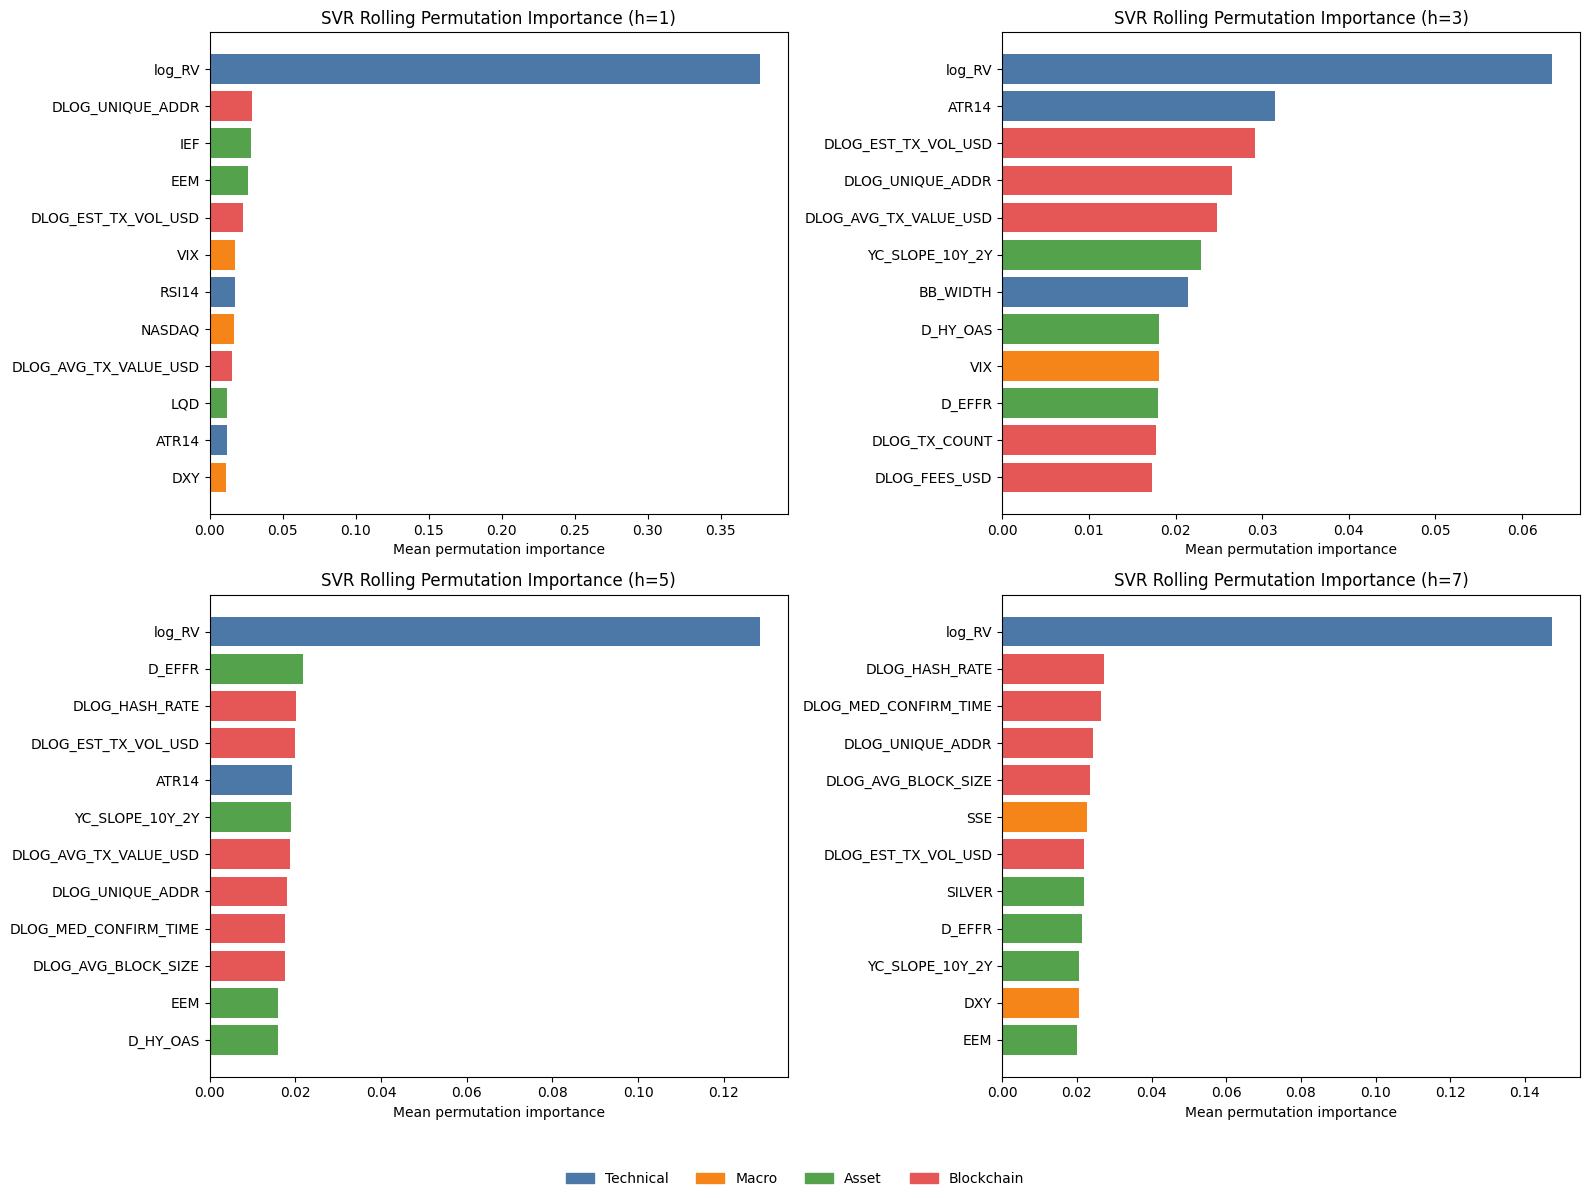

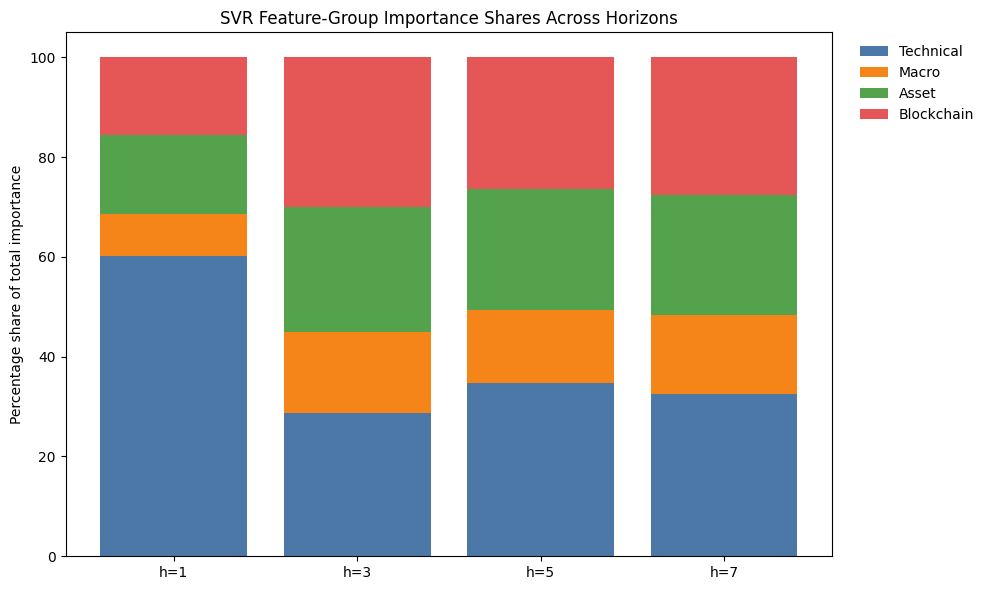

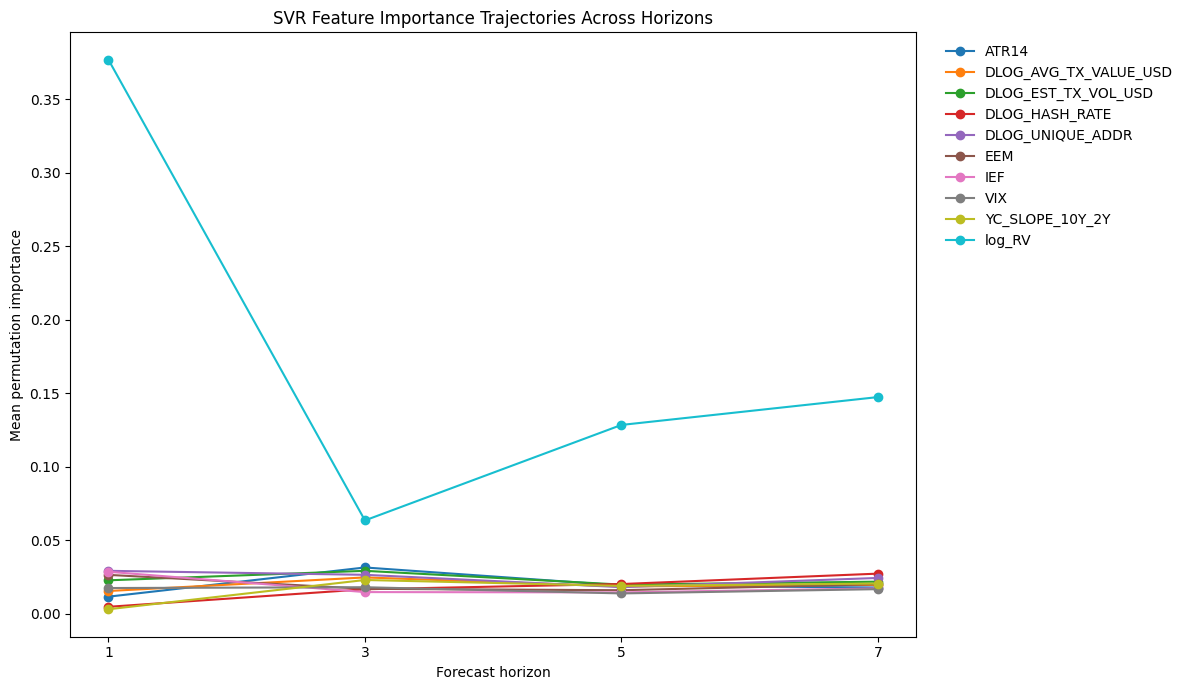

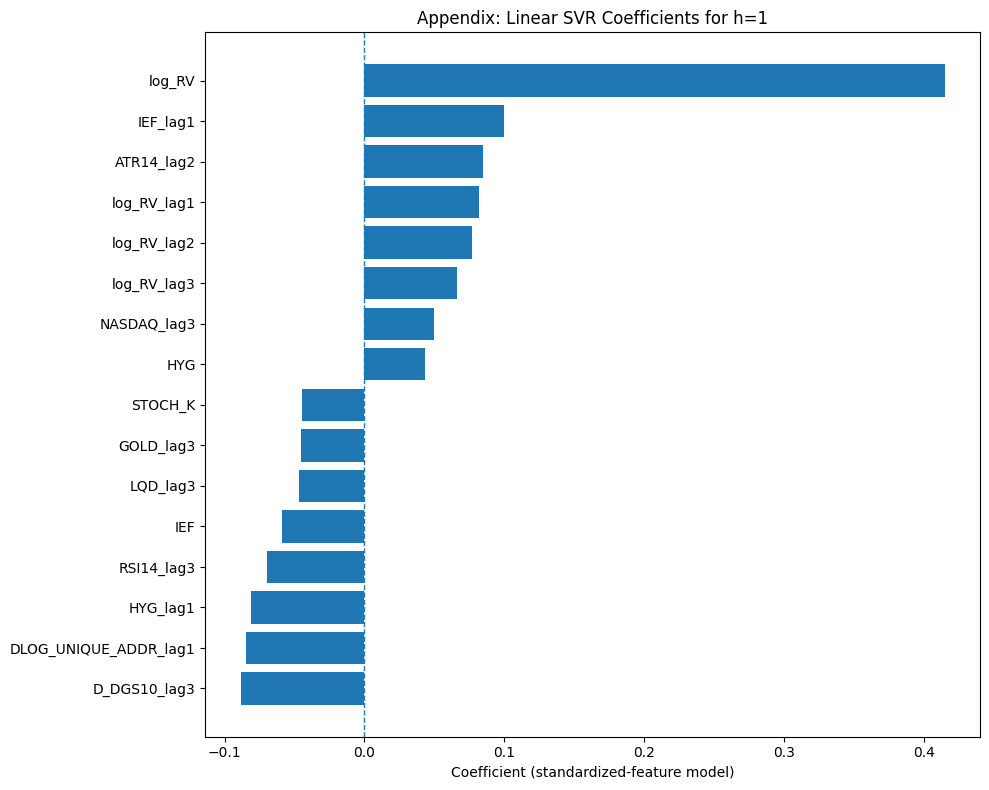

In [15]:
# Figure 1: Top-feature 2x2 grid
TOP_N = 12

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, h in zip(axes, HORIZONS):
    df_h = imp_all[imp_all["h"] == h].copy()
    top = df_h.head(TOP_N).sort_values("mean_perm_importance", ascending=True)

    colors = top["group"].map(GROUP_COLORS)

    ax.barh(top["feature"], top["mean_perm_importance"], color=colors)
    ax.set_title(f"SVR Rolling Permutation Importance (h={h})")
    ax.set_xlabel("Mean permutation importance")
    ax.set_ylabel("")

# Legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[g])
    for g in GROUP_ORDER if g in imp_all["group"].unique()
]
labels = [g for g in GROUP_ORDER if g in imp_all["group"].unique()]
fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(OUT_DIR, "svr_top_features_2x2.png"), dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: 100% stacked bar chart of group shares by horizon
pivot_group = (
    group_all.pivot(index="h", columns="group", values="pct_share")
    .fillna(0)
)

existing_groups = [g for g in GROUP_ORDER if g in pivot_group.columns]
pivot_group = pivot_group[existing_groups]

fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(pivot_group))
x = np.arange(len(pivot_group.index))

for g in existing_groups:
    vals = pivot_group[g].values
    ax.bar(x, vals, bottom=bottom, label=g, color=GROUP_COLORS.get(g, "#999999"))
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"h={h}" for h in pivot_group.index])
ax.set_ylabel("Percentage share of total importance")
ax.set_title("SVR Feature-Group Importance Shares Across Horizons")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "svr_group_share_stacked.png"), dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: Importance trajectories across horizons
top_features = (
    imp_all.groupby("feature", as_index=False)["mean_perm_importance"]
    .mean()
    .sort_values("mean_perm_importance", ascending=False)
    .head(10)["feature"]
    .tolist()
)

traj = imp_all[imp_all["feature"].isin(top_features)].copy()
traj_pivot = traj.pivot(index="h", columns="feature", values="mean_perm_importance")

fig, ax = plt.subplots(figsize=(12, 7))

for feat in traj_pivot.columns:
    ax.plot(traj_pivot.index, traj_pivot[feat], marker="o", label=feat)

ax.set_xticks(HORIZONS)
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Mean permutation importance")
ax.set_title("SVR Feature Importance Trajectories Across Horizons")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "svr_importance_trajectories.png"), dpi=300, bbox_inches="tight")
plt.show()

# Appendix Figure: y_h1 linear coefficients
coef_path = os.path.join(IN_DIR, "svr_yh1_linear_coefficients.csv")
if os.path.exists(coef_path):
    coef_df = pd.read_csv(coef_path)

    top_pos = coef_df.sort_values("coef", ascending=False).head(8)
    top_neg = coef_df.sort_values("coef", ascending=True).head(8)

    coef_plot = pd.concat([top_neg, top_pos], ignore_index=True)
    coef_plot = coef_plot.sort_values("coef", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(coef_plot["feature"], coef_plot["coef"])
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title("Appendix: Linear SVR Coefficients for h=1")
    ax.set_xlabel("Coefficient (standardized-feature model)")
    ax.set_ylabel("")

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "svr_yh1_linear_coefficients.png"), dpi=300, bbox_inches="tight")
    plt.show()